# Deep Learning Assignment 1


- Data is loaded from a local `data/` folder.
- Figures are saved into an `outputs/` folder with informative filenames.
- Cells are ordered so dependencies are explicit and minimal.

In [1]:
# %% [markdown]
# # Deep Learning Assignment 1

# %%
%matplotlib inline
import os, itertools, random, copy, gc, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

notebook_dir = Path.cwd()
DATA_ROOT = notebook_dir / "data"
OUTPUTS_DIR = notebook_dir / "outputs" / "vanilla"
MODEL_SAVE_DIR = OUTPUTS_DIR / "models"

# ONLY DEFINED ONCE HERE!
RESULTS_PATH = OUTPUTS_DIR / "phase_a_grid_results.pkl" 

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Weights will be saved to: {MODEL_SAVE_DIR}")

Using device: cuda
Weights will be saved to: /home/raveco/deep_learning_ass1/outputs/vanilla/models


In [2]:
# %%
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(42)
g = torch.Generator()
g.manual_seed(42)

In [3]:
# %%
def get_train_val_test_data(validation_size=5000, train_transforms=transforms.ToTensor(), test_transforms=transforms.ToTensor()):
    full_train_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=train_transforms)
    full_val_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=test_transforms)
    test_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=test_transforms)

    total_train_size = len(full_train_dataset)
    train_size = total_train_size - validation_size
    indices = torch.randperm(total_train_size).tolist()

    return (Subset(full_train_dataset, indices[:train_size]), 
            Subset(full_val_dataset, indices[train_size:]), 
            test_dataset)

train_dataset, val_dataset, test_dataset = get_train_val_test_data()
print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)} | Test images: {len(test_dataset)}")

/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train images: 45000 | Val images: 5000 | Test images: 10000


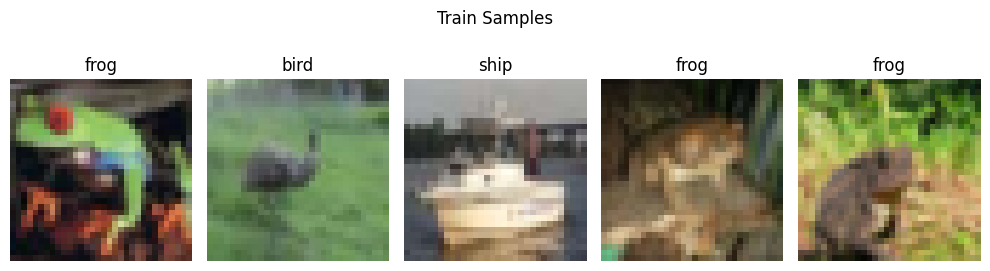

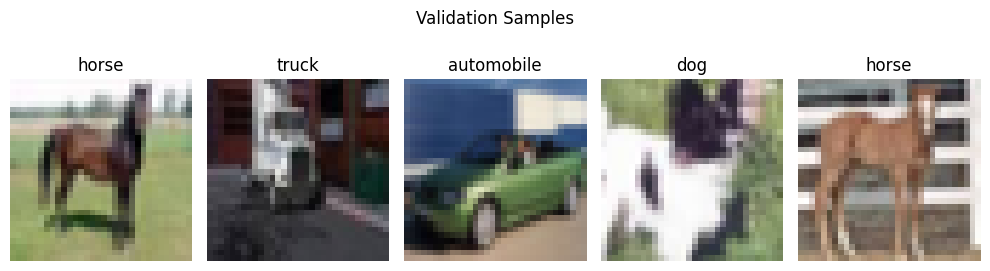

In [4]:
# %%
def save_figure(fig, filename):
    output_path = OUTPUTS_DIR / filename
    fig.savefig(output_path, bbox_inches="tight")
    return output_path

def show_images(dataset, num_images=5, title=""):
    label_names = dataset.dataset.classes if hasattr(dataset, "dataset") else dataset.classes
    fig, axes = plt.subplots(1, num_images, figsize=(10, 3))
    fig.suptitle(title)
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy()
        ax = axes[i] if num_images > 1 else axes
        ax.imshow(image)
        ax.set_title(label_names[label])
        ax.axis("off")
    fig.tight_layout()
    return fig

fig = show_images(train_dataset, 5, title="Train Samples")
save_figure(fig, "train_samples.png"); plt.show()

fig = show_images(val_dataset, 5, title="Validation Samples")
save_figure(fig, "validation_samples.png"); plt.show()

Image shape (C, H, W): torch.Size([3, 32, 32]) | Label: 6


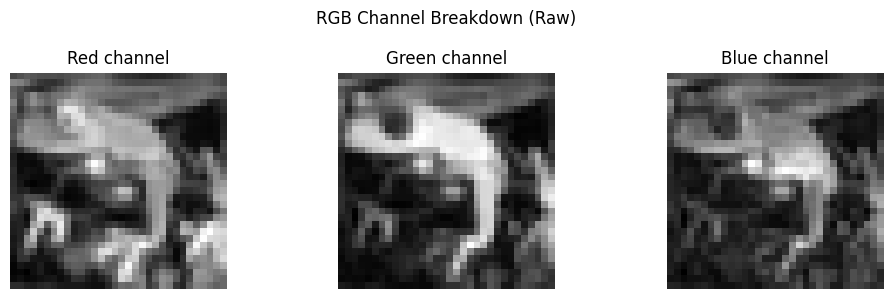

In [5]:
# %%
def debug_image_rgb(dataset):
    image, label = dataset[0] 
    print("Image shape (C, H, W):", image.shape, "| Label:", label)
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    for i, color in enumerate(["Red", "Green", "Blue"]):
        axs[i].imshow(image[i], cmap="gray")
        axs[i].set_title(f"{color} channel")
        axs[i].axis("off")
    fig.suptitle("RGB Channel Breakdown (Raw)")
    fig.tight_layout()
    return fig

fig_rgb = debug_image_rgb(train_dataset)
save_figure(fig_rgb, "debug_rgb_channels.png"); plt.show()

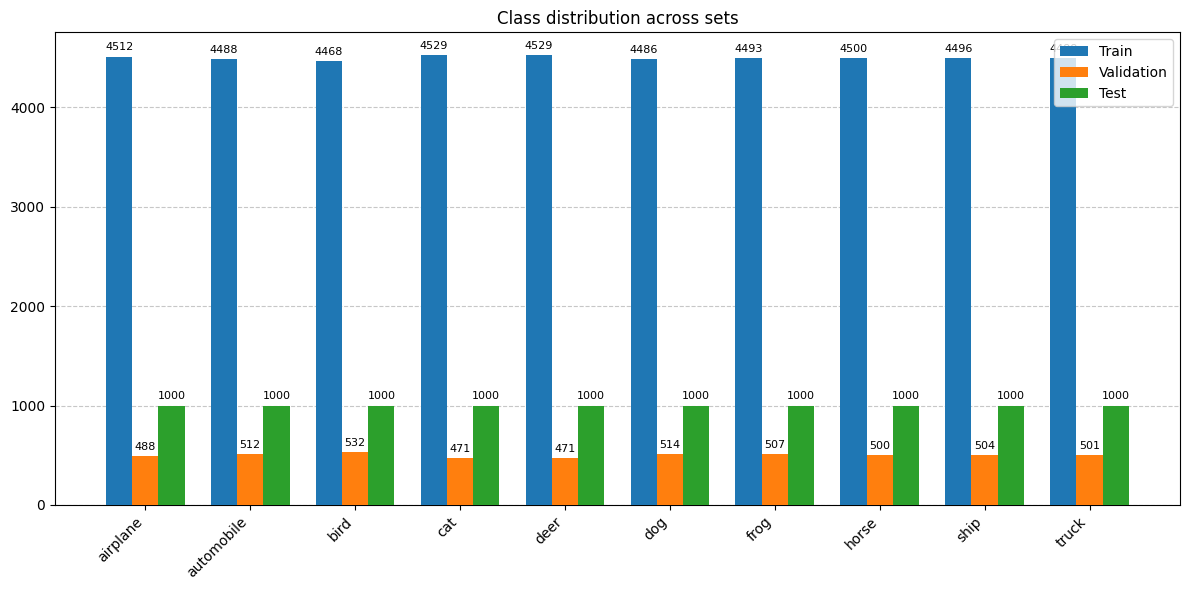

In [7]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_class_distribution(train_dataset, val_dataset, test_dataset):
    label_names = test_dataset.classes
    num_classes = len(label_names)
    train_counts, val_counts, test_counts = np.zeros(num_classes), np.zeros(num_classes), np.zeros(num_classes)

    for idx in train_dataset.indices: train_counts[train_dataset.dataset.targets[idx]] += 1
    for idx in val_dataset.indices: val_counts[val_dataset.dataset.targets[idx]] += 1
    for label in test_dataset.targets: test_counts[label] += 1

    x = np.arange(num_classes)
    bar_width = 0.25
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Store the returned bars in variables and set zorder so they stay in front of grid lines
    bars_train = ax.bar(x - bar_width, train_counts, width=bar_width, label="Train", zorder=3)
    bars_val = ax.bar(x, val_counts, width=bar_width, label="Validation", zorder=3)
    bars_test = ax.bar(x + bar_width, test_counts, width=bar_width, label="Test", zorder=3)

    # 1. Print the result numbers above each bar
    # padding=3 adds a tiny gap between the bar and the text
    ax.bar_label(bars_train, padding=3, fmt='%d', fontsize=8)
    ax.bar_label(bars_val, padding=3, fmt='%d', fontsize=8)
    ax.bar_label(bars_test, padding=3, fmt='%d', fontsize=8)

    # 2. Add horizontal lines at every 1k values on the y-axis
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))
    ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.set_title("Class distribution across sets")
    
    # Move legend slightly out of the way so it doesn't block the new text labels
    ax.legend(loc='upper right') 
    fig.tight_layout()
    return fig

fig_dist = plot_class_distribution(train_dataset, val_dataset, test_dataset)
save_figure(fig_dist, "class_distribution_train_val_test.png")
plt.show()

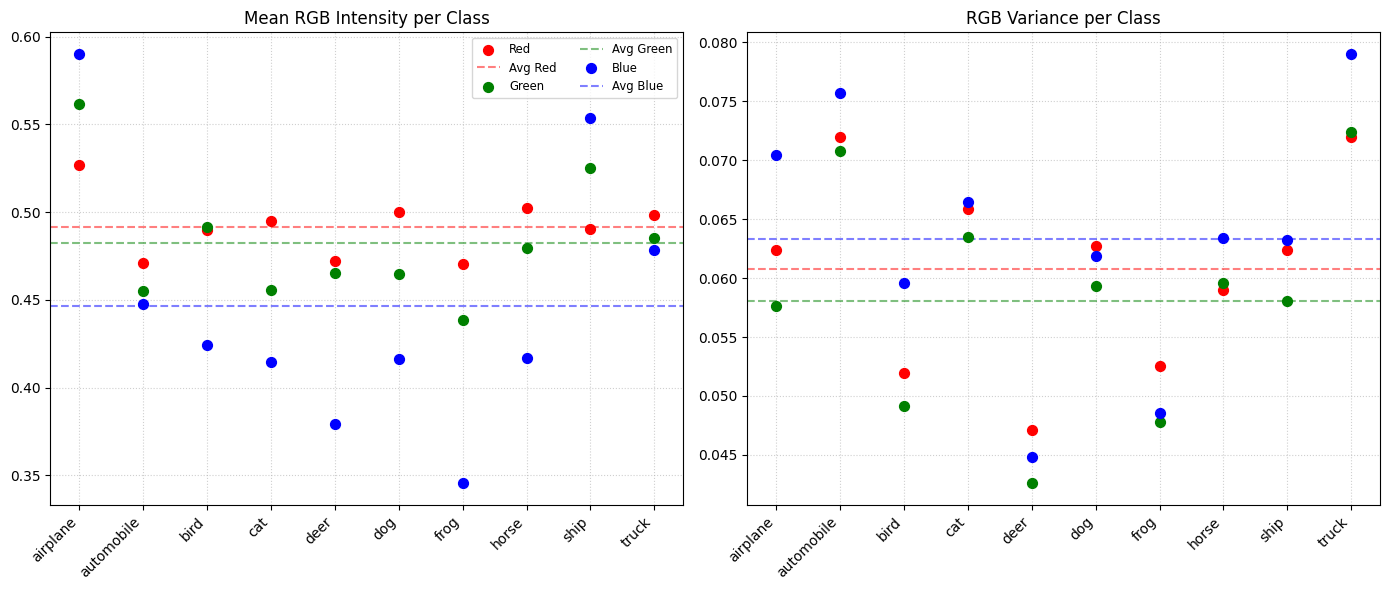

In [10]:
def compute_class_rgb_stats(dataset):
    num_classes = len(dataset.dataset.classes)
    pixel_sum, pixel_sq_sum, pixel_count = torch.zeros(num_classes, 3), torch.zeros(num_classes, 3), torch.zeros(num_classes)

    for idx in dataset.indices:
        img, label = dataset.dataset[idx] 
        img = img.view(3, -1) 
        pixel_sum[label] += img.sum(dim=1)
        pixel_sq_sum[label] += (img ** 2).sum(dim=1)
        pixel_count[label] += img.shape[1]

    class_means = pixel_sum / pixel_count.unsqueeze(1)
    class_vars = (pixel_sq_sum / pixel_count.unsqueeze(1)) - class_means**2
    return class_means.numpy(), class_vars.numpy()

def plot_rgb_stats(class_means, class_vars, class_names):
    x = np.arange(len(class_names))
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = ['r', 'g', 'b']
    labels = ["Red", "Green", "Blue"]

    # Calculate global averages (mean of all classes) for the reference lines
    global_means = np.mean(class_means, axis=0)
    global_vars = np.mean(class_vars, axis=0)

    # 1. Mean RGB Intensity Plot
    for i in range(3):
        # Scatter plot for each class (NO connecting lines)
        axes[0].scatter(x, class_means[:, i], color=colors[i], marker='o', label=labels[i], s=50, zorder=3)
        # Horizontal dashed line for the global mean of that color
        axes[0].axhline(global_means[i], color=colors[i], linestyle='--', alpha=0.5, label=f'Avg {labels[i]}', zorder=2)

    axes[0].set_title("Mean RGB Intensity per Class")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].grid(True, linestyle=':', alpha=0.6, zorder=0)
    axes[0].legend(loc='upper right', fontsize='small', ncol=2)

    # 2. RGB Variance Plot
    for i in range(3):
        # Scatter plot for each class (NO connecting lines)
        axes[1].scatter(x, class_vars[:, i], color=colors[i], marker='o', s=50, zorder=3)
        # Horizontal dashed line for the global average variance of that color
        axes[1].axhline(global_vars[i], color=colors[i], linestyle='--', alpha=0.5, zorder=2)

    axes[1].set_title("RGB Variance per Class")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].grid(True, linestyle=':', alpha=0.6, zorder=0)

    fig.tight_layout()
    return fig

# Execute the updated logic
class_means, class_vars = compute_class_rgb_stats(train_dataset)
fig_rgb_stats = plot_rgb_stats(class_means, class_vars, train_dataset.dataset.classes)

# Save and show (updated filename)
save_figure(fig_rgb_stats, "rgb_stats_per_class_scatter.png")
plt.show()

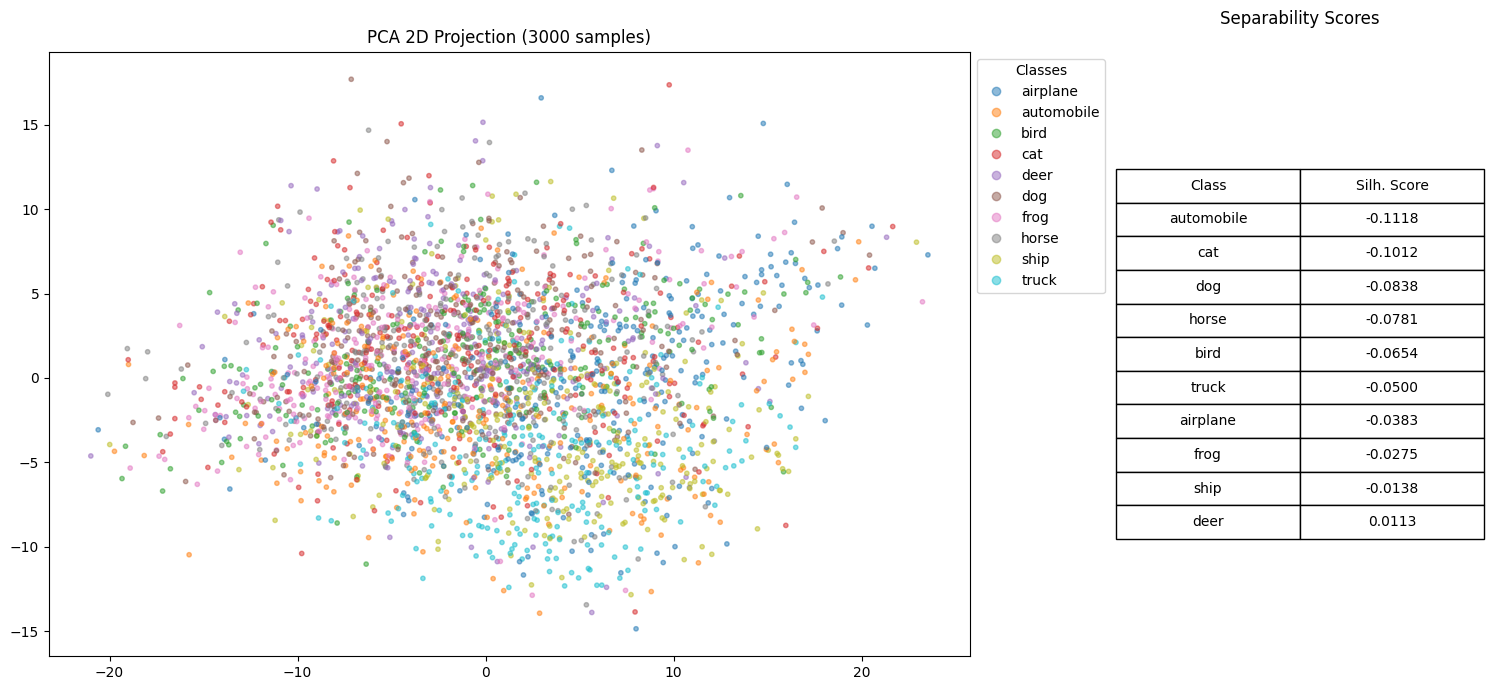

In [11]:
# %%
def plot_combined_analysis(dataset, num_samples=3000):
    images, labels = [], []
    for idx in dataset.indices[:num_samples]:
        img, lbl = dataset.dataset[idx]
        images.append(img.view(-1).numpy())
        labels.append(lbl)
    
    images, labels = np.array(images), np.array(labels)
    class_names = dataset.dataset.classes

    projected = PCA(n_components=2).fit_transform(images)
    sample_scores = silhouette_samples(images, labels)
    
    class_scores = [[class_names[i], f"{np.mean(sample_scores[labels == i]):.4f}"] for i in range(len(class_names))]
    class_scores.sort(key=lambda x: float(x[1]))

    fig, (ax_plot, ax_table) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [3, 1]})
    scatter = ax_plot.scatter(projected[:, 0], projected[:, 1], c=labels, cmap='tab10', alpha=0.5, s=10)
    handles, _ = scatter.legend_elements()
    ax_plot.legend(handles, class_names, title="Classes", loc="upper left", bbox_to_anchor=(1, 1))
    ax_plot.set_title(f"PCA 2D Projection ({num_samples} samples)")

    ax_table.axis('off')
    table = ax_table.table(cellText=class_scores, colLabels=["Class", "Silh. Score"], loc='center', cellLoc='center')
    table.scale(1.2, 1.8); ax_table.set_title("Separability Scores", pad=20)
    fig.tight_layout()
    return fig

fig_combined = plot_combined_analysis(train_dataset, num_samples=3000)
save_figure(fig_combined, "pca_with_silhouette_table.png"); plt.show()

In [ ]:
# %%
def init_weights(model, init_type='kaiming'):
    def init_func(m):
        if isinstance(m, nn.Linear):
            if init_type == 'kaiming': nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif init_type == 'xavier': nn.init.xavier_normal_(m.weight)
            if m.bias is not None: nn.init.constant_(m.bias, 0)
    model.apply(init_func)

def train(model, optimizer, loss_fn, train_loader, val_loader=None, epochs=10, device=device, scheduler=None, exp_name="Experiment", trial=None):
    model.to(device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "stop_reason": "completed"}
    best_val_loss, best_val_acc, patience_counter = float('inf'), 0.0, 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

        if scheduler is not None: scheduler.step()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_train / total_train
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)

        if val_loader:
            model.eval()
            val_running_loss, correct_val, total_val = 0.0, 0, 0
            with torch.no_grad():
                for v_in, v_lab in val_loader:
                    v_in, v_lab = v_in.to(device), v_lab.to(device)
                    v_out = model(v_in)
                    val_running_loss += loss_fn(v_out, v_lab).item() * v_in.size(0)
                    _, v_pred = v_out.max(1)
                    total_val += v_lab.size(0)
                    correct_val += v_pred.eq(v_lab).sum().item()

            val_loss = val_running_loss / len(val_loader.dataset)
            val_acc = correct_val / total_val
            history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
            
            print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), MODEL_SAVE_DIR / f"{exp_name}_best.pth")

            if trial is not None:
                trial.report(val_acc, epoch)

            if trial is None:
                if epoch == 7 and val_acc < 0.35:
                    print(f"⚠️ [{exp_name}] Early stop: Poor performance at epoch 8")
                    history["stop_reason"] = "early_stop_bad_start"; break

                if val_loss < best_val_loss: best_val_loss = val_loss; patience_counter = 0 
                else: patience_counter += 1

                massive_overfit = (val_loss - train_loss) > 0.8 
                if patience_counter >= 5 or massive_overfit:
                    reason = "massive_divergence" if massive_overfit else "patience_exceeded"
                    print(f"🛑 [{exp_name}] Early Stopped ({reason}).")
                    history["stop_reason"] = f"early_stopped_overfit_{reason}"; break

    return history

def test(model, test_loader, loss_fn, device=device):
    model.to(device); model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += loss_fn(outputs, labels).item() * inputs.size(0)
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
    return test_loss / len(test_loader.dataset), correct / total

In [10]:
# %%
class VanillaMLP(nn.Module):
    def __init__(self, input_size=3072, hidden_dims=[512, 256], num_classes=10, activation_name='relu'):
        super(VanillaMLP, self).__init__()
        acts = {'relu': nn.ReLU(), 'leaky_relu': nn.LeakyReLU(0.01), 'gelu': nn.GELU(), 'sigmoid': nn.Sigmoid(), 'tanh': nn.Tanh()}
        activation = acts.get(activation_name.lower(), nn.ReLU())

        layers = []
        prev_dim = input_size
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(activation)
            prev_dim = dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))

In [11]:
# %%
def plot_training_results(results_dict, exp_name=None):
    if exp_name is None: exp_name = list(results_dict.keys())[-1]
    data = results_dict[exp_name]
    history = data['history']
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Performance: {exp_name}', fontsize=16, fontweight='bold')

    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 's-', label='Val Loss')
    ax1.set_title('Cross Entropy Loss'); ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 's-', label='Val Acc')
    ax2.set_title('Accuracy Score'); ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)

    val_acc_val = float(history['val_acc'][-1]) if history['val_acc'] else 0.0
    fig.text(0.5, 0.02, f"Final Val Acc: {val_acc_val:.4f} | Stop Reason: {history['stop_reason']}", ha='center')

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(OUTPUTS_DIR / f"{exp_name}_performance.png", dpi=300, bbox_inches='tight')
    plt.show()

In [12]:
# %%
print("🚀 Starting Phase A: Focused Grid Search...")

if RESULTS_PATH.exists():
    print(f"📂 Found existing results file. Resuming from {RESULTS_PATH}...")
    with open(RESULTS_PATH, "rb") as f: results_log = pickle.load(f)
else:
    results_log = {}

grid_params = {
    "hidden_dims": [[1024], [512, 256], [1024, 512, 128], [1024, 512, 256, 128]], 
    "activation": ["relu", "leaky_relu", "sigmoid"], 
    "lr": [1e-2, 1e-3, 5e-4, 1e-4, 1e-5],                          
    "scheduler": ["none", "cosine", "step"]                          
}

keys, values = zip(*grid_params.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

batch_size = 128; epochs = 50
loss_fn = nn.CrossEntropyLoss()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

for i, config in enumerate(experiments):
    act, lr, sch = config['activation'], config['lr'], config['scheduler']
    exp_name = f"Exp_{i:03d}_L{len(config['hidden_dims'])}_W{config['hidden_dims'][0]}_{act}_lr{lr}_{sch}"
    
    if exp_name in results_log:
        print(f"⏩ Skipping {exp_name} (already completed).")
        continue

    print(f"\n🔹 Running {exp_name} ({i+1}/{len(experiments)})")
    model = VanillaMLP(hidden_dims=config["hidden_dims"], activation_name=act).to(device)
    init_weights(model, init_type='xavier' if act == "sigmoid" else 'kaiming')

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    config["optimizer"] = "adam"

    if sch == "step": scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)
    elif sch == "cosine": scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    else: scheduler = None

    history = train(model, optimizer, loss_fn, train_loader, val_loader, epochs=epochs, device=device, scheduler=scheduler, exp_name=exp_name)
    results_log[exp_name] = {"config": config, "history": history}
    
    with open(RESULTS_PATH, "wb") as f: pickle.dump(results_log, f)

print(f"\n🎉 All Grid Search runs completed successfully!")

🚀 Starting Phase A: Focused Grid Search...
📂 Found existing results file. Resuming from /home/raveco/deep_learning_ass1/outputs/vanilla/phase_a_grid_results.pkl...
⏩ Skipping Exp_000_L1_W1024_relu_lr0.01_none (already completed).
⏩ Skipping Exp_001_L1_W1024_relu_lr0.01_cosine (already completed).
⏩ Skipping Exp_002_L1_W1024_relu_lr0.01_step (already completed).
⏩ Skipping Exp_003_L1_W1024_relu_lr0.001_none (already completed).
⏩ Skipping Exp_004_L1_W1024_relu_lr0.001_cosine (already completed).
⏩ Skipping Exp_005_L1_W1024_relu_lr0.001_step (already completed).
⏩ Skipping Exp_006_L1_W1024_relu_lr0.0005_none (already completed).
⏩ Skipping Exp_007_L1_W1024_relu_lr0.0005_cosine (already completed).
⏩ Skipping Exp_008_L1_W1024_relu_lr0.0005_step (already completed).
⏩ Skipping Exp_009_L1_W1024_relu_lr0.0001_none (already completed).
⏩ Skipping Exp_010_L1_W1024_relu_lr0.0001_cosine (already completed).
⏩ Skipping Exp_011_L1_W1024_relu_lr0.0001_step (already completed).
⏩ Skipping Exp_012_L1

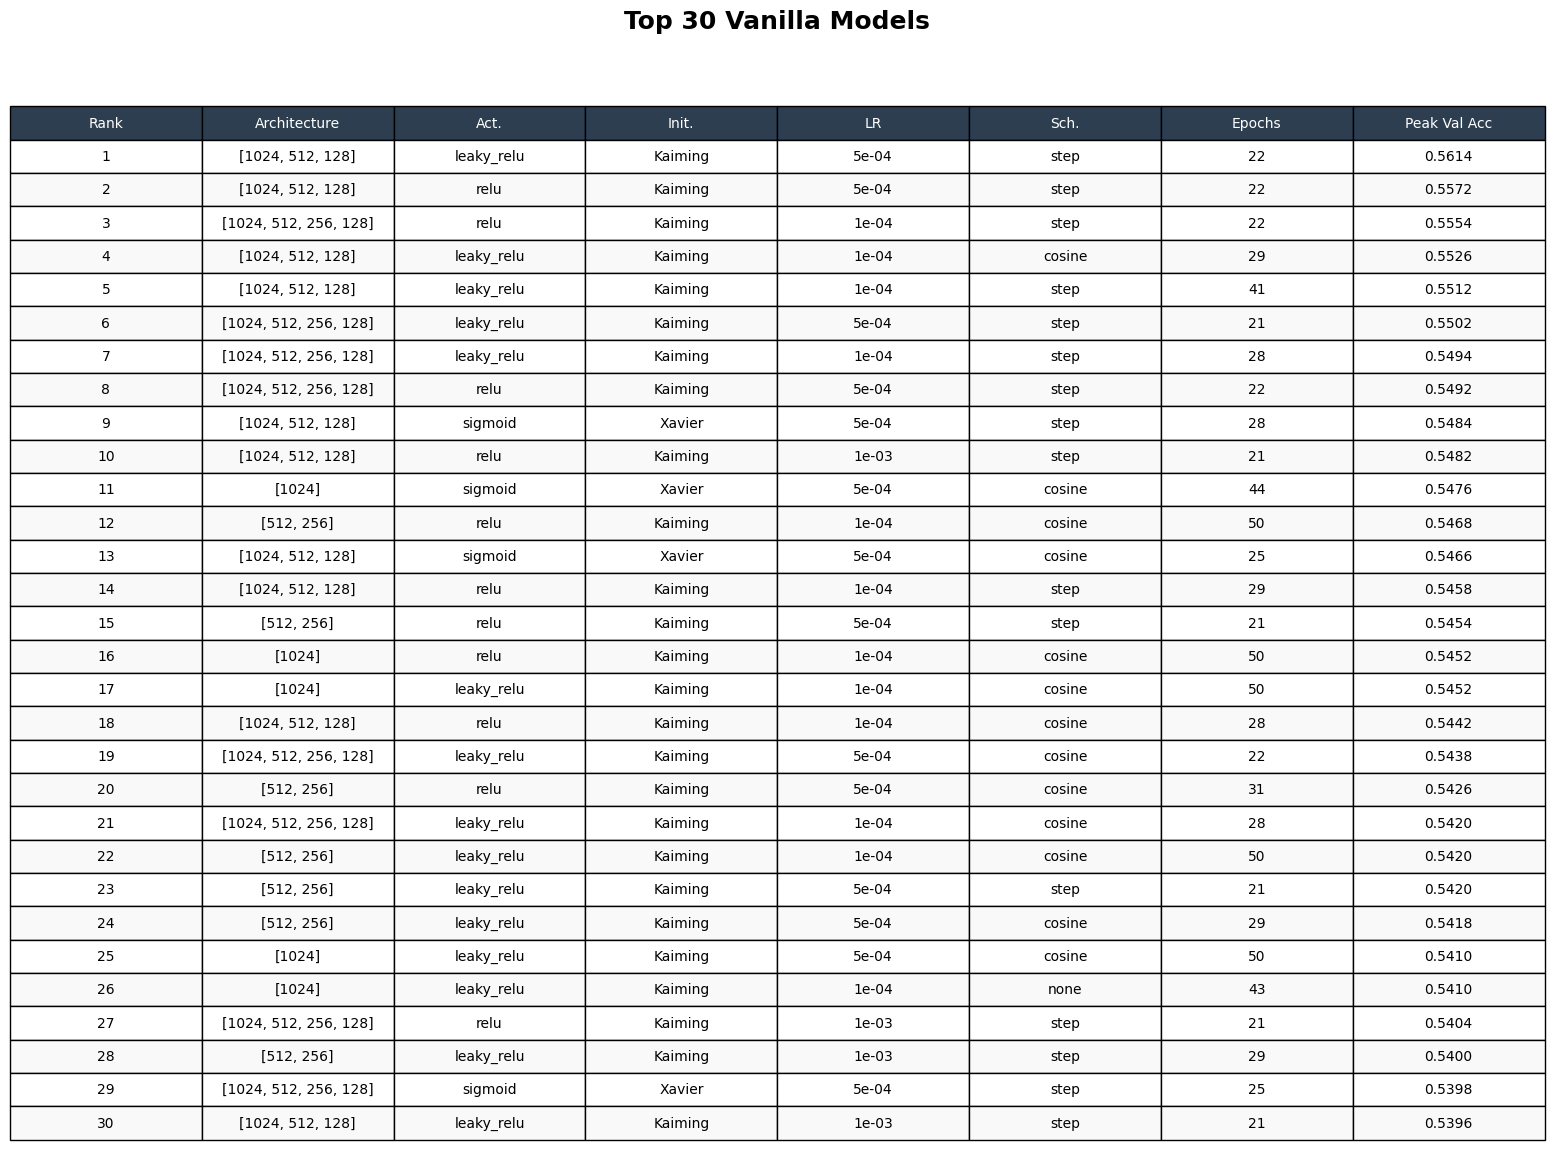

In [13]:
# %%
# %%
def analyze_top_results(results_path, top_n=30):
    if not results_path.exists(): return
    with open(results_path, "rb") as f: log = pickle.load(f)

    summary_data = []
    for name, data in log.items():
        c, h = data['config'], data['history']
        val_accs = h.get('val_acc', [])
        
        # Determine init based on the exact logic executed in the script
        act_name = c['activation'].lower()
        init_method = "Xavier" if act_name == "sigmoid" else "Kaiming"
        
        summary_data.append({
            "Architecture": str(c['hidden_dims']),
            "Act.": act_name,
            "Init.": init_method,
            "LR": f"{c['lr']:.0e}",
            "Sch.": c['scheduler'],
            "Epochs": len(val_accs),
            "Peak Val Acc": max(val_accs) if val_accs else 0
        })

    # Sort, take top N, and reset index
    df = pd.DataFrame(summary_data).sort_values(by="Peak Val Acc", ascending=False).head(top_n).reset_index(drop=True)
    
    # Insert Rank column at the very beginning
    df.insert(0, 'Rank', df.index + 1)
    
    # Format accuracy
    df['Peak Val Acc'] = df['Peak Val Acc'].map(lambda x: f"{x:.4f}")

    # Plotting
    fig, ax = plt.subplots(figsize=(18, 14)); ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    table.scale(1.1, 2.0)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0: 
            cell.get_text().set_color('white')
            cell.set_facecolor('#2c3e50')
        elif row % 2 == 0: 
            cell.set_facecolor('#f9f9f9')

    plt.title(f"Top {top_n} Vanilla Models", fontsize=18, fontweight='bold', pad=40)
    plt.savefig(OUTPUTS_DIR / "top_30_vanilla.png", dpi=300, bbox_inches='tight')
    plt.show()

analyze_top_results(RESULTS_PATH)

🏆 Best Model Found: Exp_113_L3_W1024_leaky_relu_lr0.0005_step
⭐ Peak Validation Accuracy: 0.5614


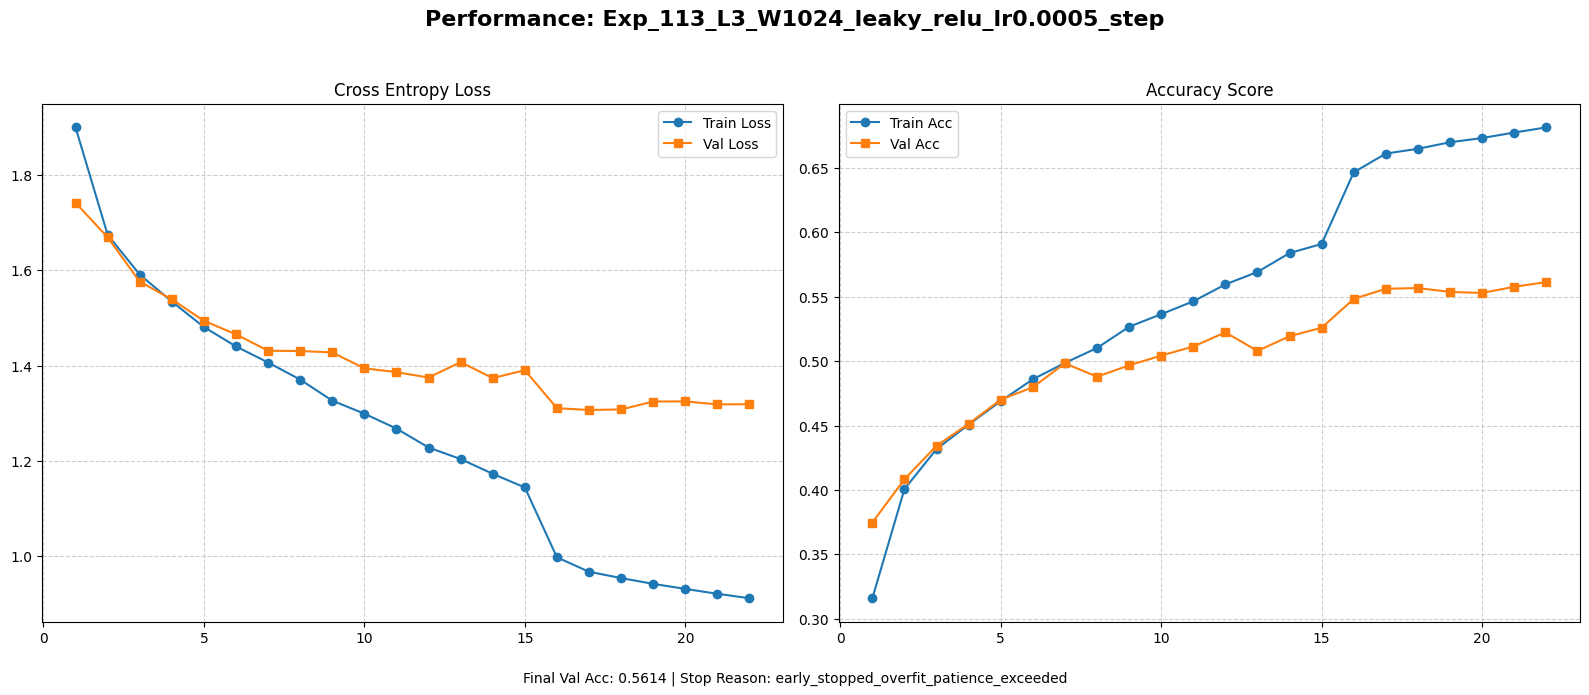

In [14]:
# %% [markdown]
# ## Plot Best Ranked Vanilla Model
# Automatically finds the top-performing model from Phase A and visualizes its training curves.

# %%
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, "rb") as f:
        results_log = pickle.load(f)

    # Find the experiment with the maximum peak validation accuracy
    best_exp_name = None
    best_val_acc = -1

    for exp_name, data in results_log.items():
        val_accs = data['history'].get('val_acc', [0])
        peak_acc = max(val_accs) if val_accs else 0
        
        if peak_acc > best_val_acc:
            best_val_acc = peak_acc
            best_exp_name = exp_name

    print(f"🏆 Best Model Found: {best_exp_name}")
    print(f"⭐ Peak Validation Accuracy: {best_val_acc:.4f}")

    # Plot using your existing function from Cell 11
    plot_training_results(results_log, exp_name=best_exp_name)
else:
    print(f"❌ Results file not found at {RESULTS_PATH}")

In [ ]:
# %% [markdown]
# ## Phase A: Final Test Set Evaluation
# Evaluating the Chosen VanillaMLP on the unseen test dataset.

# %%
if 'best_exp_name' in locals() and best_exp_name:
    print(f"Loading best baseline model: {best_exp_name}")
    
    # --- FIX: Initialize the test_loader ---
    # We use a batch size of 128 (same as training) and shuffle=False for testing
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    
    # 1. Reconstruct the best configuration from the log
    best_config = results_log[best_exp_name]['config']
    
    # 2. Initialize the model with these exact parameters
    chosen_vanilla_model = VanillaMLP(
        hidden_dims=best_config['hidden_dims'], 
        activation_name=best_config['activation']
    ).to(device)
    
    # 3. Load the saved best weights
    weights_path = MODEL_SAVE_DIR / f"{best_exp_name}_best.pth"
    chosen_vanilla_model.load_state_dict(torch.load(weights_path, map_location=device))
    
    # 4. Evaluate on the test set using your existing test() function
    test_loss, test_acc = test(chosen_vanilla_model, test_loader, loss_fn, device=device)
    
    print("\n" + "="*50)
    print("🏆 Final Vanilla MLP Test Set Metrics")
    print("="*50)
    print(f"i.  Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
    print(f"ii. Loss:     {test_loss:.4f}")
    print("="*50)
else:
    print("❌ Could not find 'best_exp_name'. Please run the previous cell first.")

Loading best baseline model: Exp_113_L3_W1024_leaky_relu_lr0.0005_step

🏆 Final Vanilla MLP Test Set Metrics
i.  Accuracy: 0.5497 (54.97%)
ii. Loss:     1.3084


Phase B


In [ ]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_size=3072, hidden_dims=[1024, 512, 128], num_classes=10, 
                 activation_name='leaky_relu', use_batchnorm=False, dropout_rate=0.0):
        super(ImprovedMLP, self).__init__()
        
        acts = {'relu': nn.ReLU(), 'leaky_relu': nn.LeakyReLU(0.01), 'gelu': nn.GELU()}
        activation = acts.get(activation_name.lower(), nn.ReLU())

        layers = []
        prev_dim = input_size
        
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dim))
            layers.append(activation)
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(p=dropout_rate))
            prev_dim = dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1) 
        return self.model(x)


In [ ]:
# Setup improved Phase B directories and paths
IMPROVED_OUTPUTS_DIR = notebook_dir / "outputs" / "improved"
IMPROVED_MODEL_SAVE_DIR = IMPROVED_OUTPUTS_DIR / "models"
IMPROVED_RESULTS_PATH = IMPROVED_OUTPUTS_DIR / "phase_b_results.pkl"

IMPROVED_OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
IMPROVED_MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Hardcoded CIFAR-10 Stats (Calculated globally over the standard train set)
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD = [0.2470, 0.2435, 0.2616]


def get_dataloaders(config, validation_size=5000, batch_size=128):
    train_transforms_list = []
    test_transforms_list = [transforms.ToTensor()]

    if config['augmentation'] in ['crop', 'both']:
        train_transforms_list.append(transforms.RandomCrop(32, padding=4))
    if config['augmentation'] in ['rotate', 'both']:
        train_transforms_list.append(transforms.RandomRotation(15))

    train_transforms_list.append(transforms.ToTensor())

    if config['input_norm']:
        norm_layer = transforms.Normalize(CIFAR_MEAN.tolist(), CIFAR_STD.tolist())
        train_transforms_list.append(norm_layer)
        test_transforms_list.append(norm_layer)

    train_transform = transforms.Compose(train_transforms_list)
    test_transform = transforms.Compose(test_transforms_list)

    full_train = datasets.CIFAR10(root=str(DATA_ROOT), train=True, transform=train_transform, download=True)
    full_val = datasets.CIFAR10(root=str(DATA_ROOT), train=True, transform=test_transform, download=True)

    total_train_size = len(full_train)
    train_size = total_train_size - validation_size
    indices = torch.randperm(total_train_size).tolist()

    train_ds = Subset(full_train, indices[:train_size])
    val_ds = Subset(full_val, indices[train_size:])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

for i, config in enumerate(experiments):
    exp_name = config["name"]
    
    if exp_name in results_log:
        print(f"⏩ Skipping {exp_name} (already completed).")
        continue

    print(f"\n" + "="*60)
    print(f"🔹 Running {exp_name} ({i+1}/{len(experiments)})")
    print(f"🔹 Config: {config}")
    print("="*60)

    train_loader, val_loader = get_dataloaders(config)

    model = ImprovedMLP(
        hidden_dims=[1024, 512, 128], 
        activation_name='leaky_relu',
        use_batchnorm=config['batchnorm'],
        dropout_rate=config['dropout']
    ).to(device)
    init_weights(model)

    current_lr = config.get('custom_lr', 5e-4) # Defaults to 5e-4 if not specified
    optimizer = torch.optim.Adam(model.parameters(), lr=current_lr, weight_decay=config['l2_wd'])
    
    history = train(
        model=model, 
        optimizer=optimizer, 
        loss_fn=loss_fn, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        epochs=50, 
        device=device, 
        exp_name=exp_name,
        l1_lambda=config['l1_lambda']
    )

    results_log[exp_name] = {"config": config, "history": history}
    plot_training_results(results_log, exp_name=exp_name)
    
    with open(RESULTS_PATH, "wb") as f:
        pickle.dump(results_log, f)

print(f"\n🎉 Phase B Regularization Study completed successfully!")

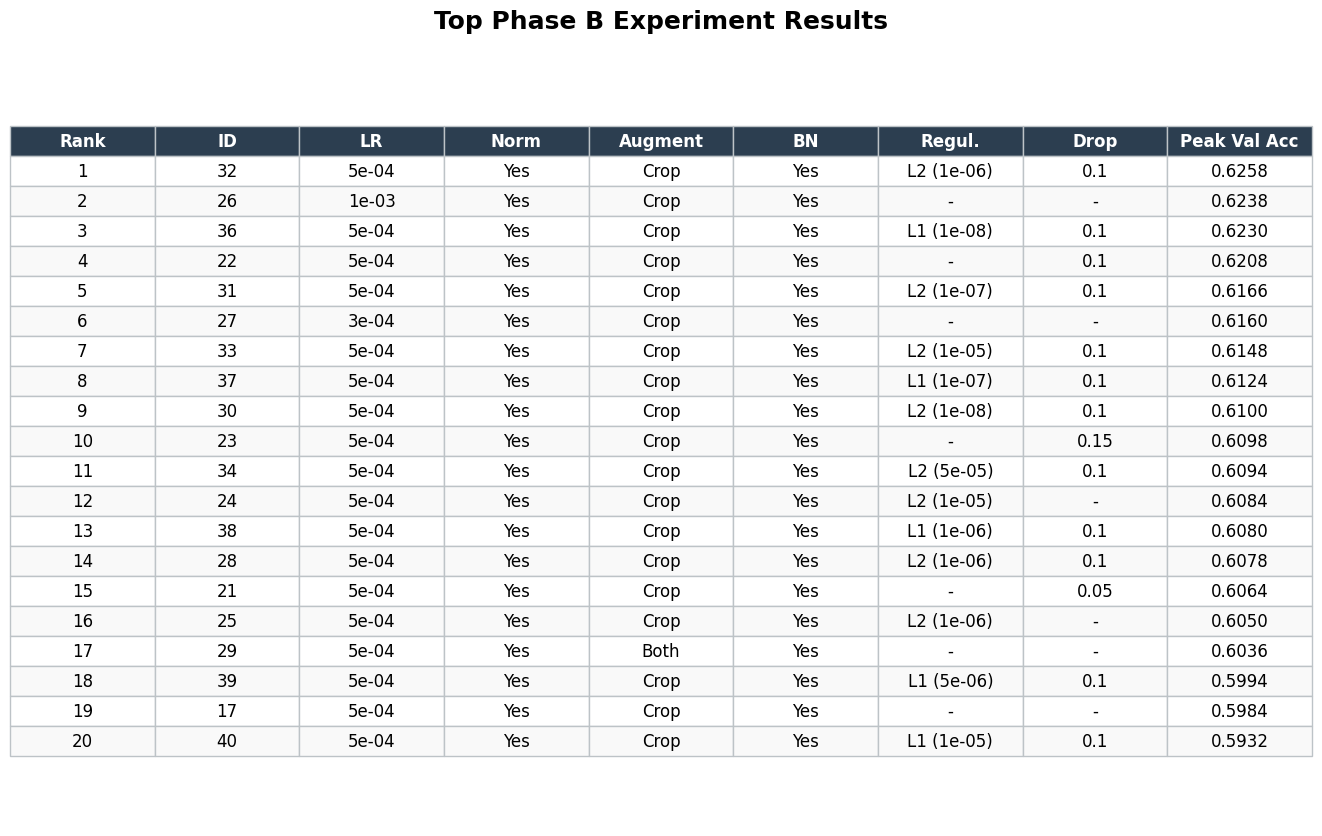

In [ ]:
def analyze_phase_b_results_clean(top_n=20):
    # Hardcoded path to the results file
    file_path = Path("outputs/improved/phase_b_results.pkl")
    
    if not file_path.exists(): 
        print(f"❌ Could not find {file_path}")
        return
        
    with open(file_path, "rb") as f: 
        log = pickle.load(f)

    summary_data = []
    for name, data in log.items():
        c = data['config']
        h = data['history']
        val_accs = h.get('val_acc', [])
        
        # Consolidation Logic for Regularization
        regul_val = "-"
        if c.get('l2_wd', 0) > 0:
            regul_val = f"L2 ({c['l2_wd']:.0e})"
        elif c.get('l1_lambda', 0) > 0:
            regul_val = f"L1 ({c['l1_lambda']:.0e})"
            
        summary_data.append({
            "ID": name.split('_')[1], # Extracts 'XX' from 'phase_B_XX...'
            "LR": f"{c.get('custom_lr', 5e-4):.0e}",
            "Norm": "Yes" if c['input_norm'] else "-",
            "Augment": c['augmentation'].title() if c['augmentation'] != "none" else "-",
            "BN": "Yes" if c['batchnorm'] else "-",
            "Regul.": regul_val,
            "Drop": str(c['dropout']) if c['dropout'] > 0 else "-",
            "Peak Val Acc": max(val_accs) if val_accs else 0
        })

    # Sort and take top N
    df = pd.DataFrame(summary_data).sort_values(by="Peak Val Acc", ascending=False).head(top_n).reset_index(drop=True)
    df.insert(0, 'Rank', df.index + 1)
    df['Peak Val Acc'] = df['Peak Val Acc'].map(lambda x: f"{x:.4f}")

    # Plotting adjustments
    fig_height = max(8, len(df) * 0.5) 
    fig, ax = plt.subplots(figsize=(14, fig_height)) 
    ax.axis('off')
    
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    
    # Table Styling
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.8) 
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#bdc3c7')
        if row == 0: 
            cell.get_text().set_color('white')
            cell.get_text().set_weight('bold')
            cell.set_facecolor('#2c3e50')
        elif row % 2 == 0: 
            cell.set_facecolor('#f9f9f9')

    plt.title("Top Phase B Experiment Results", fontsize=18, fontweight='bold', pad=20)
    
    # Hardcoded save path
    plt.savefig("outputs/improved/phase_b_top_results.png", dpi=300, bbox_inches='tight')
    plt.show()

# Just call the function directly
analyze_phase_b_results_clean(top_n=20)

In [ ]:
# %% [markdown]
# ## Evaluate Rank 1 Improved Model on Test Set
# Loading the best weights for the top-performing model and calculating final test performance.


# --- 2. Identify Rank 1 Model ---
if not RESULTS_PATH.exists():
    print(f"❌ Results file not found: {RESULTS_PATH}")
else:
    with open(RESULTS_PATH, "rb") as f:
        results_log = pickle.load(f)

    # Sort models by Peak Val Acc
    rank_list = []
    for name, data in results_log.items():
        val_accs = data['history'].get('val_acc', [])
        peak_acc = max(val_accs) if val_accs else 0
        rank_list.append((name, peak_acc, data['config']))
    
    # Sort descending: highest accuracy is at index 0
    rank_list.sort(key=lambda x: x[1], reverse=True)

    if len(rank_list) < 1:
        print("❌ No models found in results log.")
    else:
        # Index 0 is Rank 1
        rank_1_name, rank_1_val_acc, rank_1_config = rank_list[0]
        print(f"🥇 Evaluating Rank 1 (Best Model): {rank_1_name}")
        print(f"⭐ Peak Validation Acc: {rank_1_val_acc:.4f}")

        # --- 3. Prepare Test Dataloader ---
        CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
        CIFAR_STD = [0.2023, 0.1994, 0.2010]
        
        test_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
        ])

        test_ds = datasets.CIFAR10(root=str(DATA_ROOT), train=False, transform=test_transform, download=True)
        test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

        # --- 4. Initialize and Load Model ---
        # Using the config stored in the results log to reconstruct the model
        model = ImprovedMLP(
            hidden_dims=[1024, 512, 128],
            activation_name='leaky_relu',
            use_batchnorm=rank_1_config['batchnorm'],
            dropout_rate=rank_1_config['dropout']
        ).to(device)

        weights_path = MODEL_DIR / f"{rank_1_name}_best.pth"
        if weights_path.exists():
            model.load_state_dict(torch.load(weights_path, map_location=device))
            model.eval()

            # --- 5. Final Evaluation ---
            correct, total = 0, 0
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    _, predicted = outputs.max(1)
                    total += labels.size(0)
                    correct += predicted.eq(labels).sum().item()

            test_acc = correct / total
            print(f"\n✅ FINAL TEST RESULT for {rank_1_name}:")
            print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
            
            # Identify which regularization was used for the printout
            reg_type = "L2" if rank_1_config.get('l2_wd', 0) > 0 else "L1"
            reg_val = rank_1_config.get('l2_wd') if reg_type == "L2" else rank_1_config.get('l1_lambda')
            
            print(f"   Config: {reg_type}={reg_val}, Drop={rank_1_config['dropout']}, Aug={rank_1_config['augmentation']}")
        else:
            print(f"❌ Weights file not found: {weights_path}")

🥇 Evaluating Rank 1 (Best Model): B_32_L2_1e-6
⭐ Peak Validation Acc: 0.6258

✅ FINAL TEST RESULT for B_32_L2_1e-6:
   Test Accuracy: 0.6088 (60.88%)
   Config: L2=1e-06, Drop=0.1, Aug=crop


🥇 RANK 1 MODEL FOUND: B_32_L2_1e-6
------------------------------
⭐ Peak Val Acc:    0.6258
📈 Peak Train Acc:  0.6112
📉 Min Val Loss:    1.0654
📉 Min Train Loss:  1.0854
✅ Final Test Acc:  N/A
------------------------------


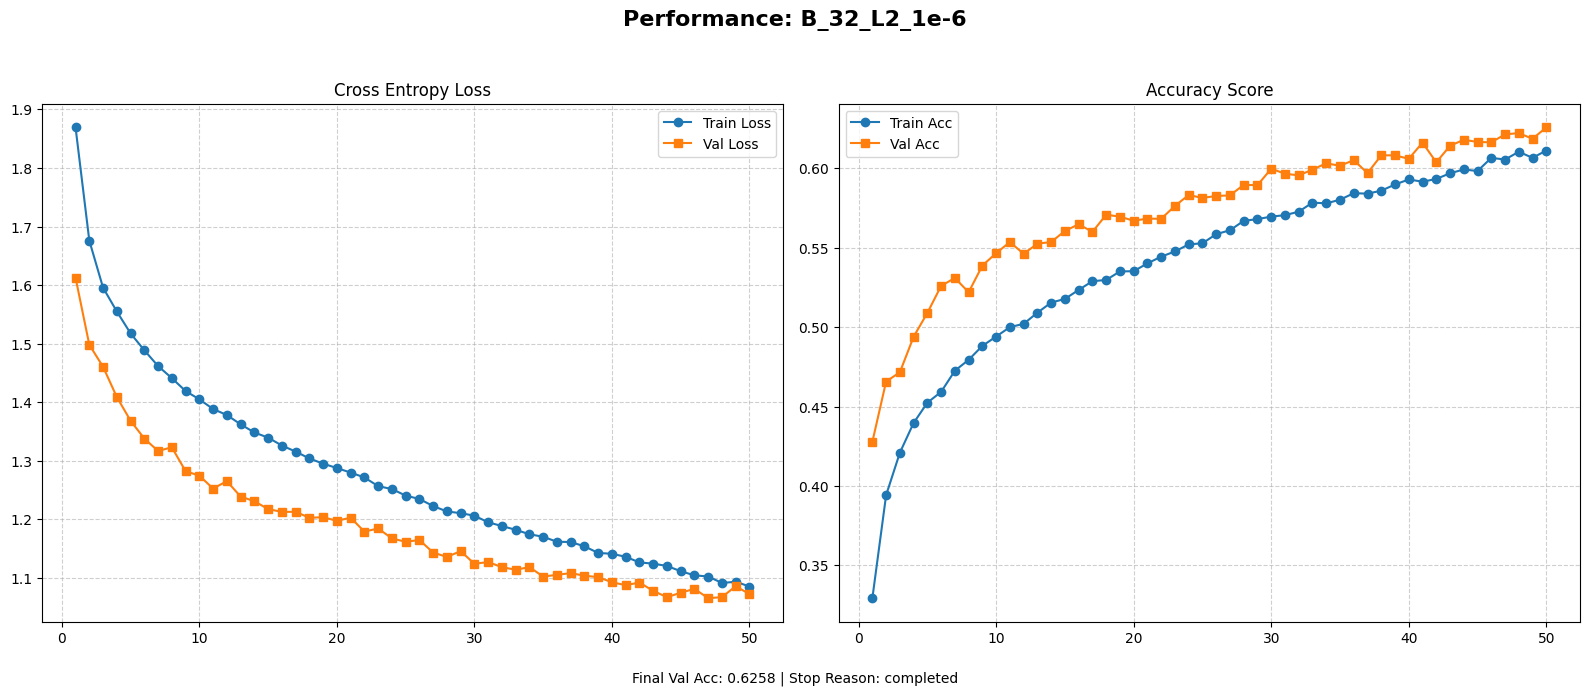

: 

In [ ]:
# %% [markdown]
# ## Plot Rank 1 Improved Model
# Automatically finds the best performing model from Phase B and visualizes its training curves and full metrics.


# Load results directly
PHASE_B_RESULTS_PATH = Path("outputs/improved/phase_b_results.pkl")

if PHASE_B_RESULTS_PATH.exists():
    with open(PHASE_B_RESULTS_PATH, "rb") as f:
        results_log = pickle.load(f)

    # 1. Create a list of (exp_name, peak_val_acc)
    rank_list = []
    for exp_name, data in results_log.items():
        val_accs = data['history'].get('val_acc', [])
        peak_acc = max(val_accs) if val_accs else 0
        rank_list.append((exp_name, peak_acc))

    # 2. Sort by accuracy (Descending)
    rank_list.sort(key=lambda x: x[1], reverse=True)

    # 3. Process Rank 1 (Index 0)
    if len(rank_list) >= 1:
        name, peak_val = rank_list[0]
        data = results_log[name]
        hist = data['history']
        
        # Extract additional stats
        peak_train_acc = max(hist.get('train_acc', [0]))
        min_train_loss = min(hist.get('train_loss', [float('inf')]))
        min_val_loss = min(hist.get('val_loss', [float('inf')]))
        test_acc = data.get('test_acc', "N/A")

        print(f"🥇 RANK 1 MODEL FOUND: {name}")
        print("-" * 30)
        print(f"⭐ Peak Val Acc:    {peak_val:.4f}")
        print(f"📈 Peak Train Acc:  {peak_train_acc:.4f}")
        print(f"📉 Min Val Loss:    {min_val_loss:.4f}")
        print(f"📉 Min Train Loss:  {min_train_loss:.4f}")
        
        test_str = f"{test_acc:.4f}" if isinstance(test_acc, (float, int)) else test_acc
        print(f"✅ Final Test Acc:  {test_str}")
        print("-" * 30)

        # 4. Plot training curves
        # Ensure plot_training_results is defined in your notebook
        plot_training_results(results_log, exp_name=name)
    else:
        print("❌ No experiments found in the results file.")
else:
    print(f"❌ Results file not found at {PHASE_B_RESULTS_PATH}")